In [1]:
import numpy as np
import pandas as pd
import os, sys
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from typing import Dict, List
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
sys.path.append('../../pseudo_gene_maize/')
from get_logits import *

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
labels_dict = {}
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(get_file_paths('labels', '../../../results/pseudo_gene_tomato/splice_junctions/')[junction], sep='\t')
    for model in ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3']:
        predicted_codon, true_tokens = predicted_masked_tokens(model, idx, tokenizer, 
                                                               base_dir='../../../results/pseudo_gene_tomato/outputs', 
                                                               chunk_size=None, JUNCTIONS=JUNCTIONS)
        label[f'predicted_codon_{model}'] = predicted_codon
    label['true_tokens'] = true_tokens
    # for Evo2 fwd
    predicted_codon = pd.read_csv(get_file_paths('evo2_fwd', '../../../results/pseudo_gene_tomato/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_fwd'] = predicted_codon[0]
    # for Evo2 rc
    predicted_codon = pd.read_csv(get_file_paths('evo2_rc', '../../../results/pseudo_gene_tomato/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_rc'] = predicted_codon[0]
    # label.loc[label['Label'].isin(['Shell', 'Cloud']), 'Label'] = 'Dispensable'
    label['Label'] = 'All'
    labels_dict[junction] = label

In [4]:
labels_dict['start_sites'].head()

,Transcript_ID,Label,predicted_codon_pcv1,predicted_codon_pcv2_1,predicted_codon_pcv2_2,predicted_codon_pcv2_3,true_tokens,predicted_codon_evo2_fwd,predicted_codon_evo2_rc
0,Solyc00g005000.3,All,AAT,ATG,ATG,ATG,ATG,AAA,AAA
1,Solyc00g005040.3,All,GTT,ATG,ATT,ATG,ATG,ATT,CAT
2,Solyc00g005050.3,All,ATG,ATG,ATG,ATG,ATG,AAA,CAT
3,Solyc00g005060.1,All,AGA,AGG,AGG,AGG,ATG,AGG,AGG
4,Solyc00g005080.2,All,AAA,AAA,AAA,AAA,AAA,TTT,TTT


In [5]:
labels_dict['start_sites']['Label'].value_counts()

Label
All    35484
Name: count, dtype: int64

In [6]:
# label_order = ['Core', 'Softcore', 'Dispensable']
label_order = ['All']
def calculate_accuracies(df, order=label_order):
    results = {}
    for label in order: 
        if label in df['Label'].values:
            group = df[df['Label'] == label].copy()
            
            # Calculate accuracy for PlantCAD models
            pcv1_acc = (group['predicted_codon_pcv1'] == group['true_tokens']).mean()
            pcv2_1_acc = (group['predicted_codon_pcv2_1'] == group['true_tokens']).mean()
            pcv2_2_acc = (group['predicted_codon_pcv2_2'] == group['true_tokens']).mean()
            pcv2_3_acc = (group['predicted_codon_pcv2_3'] == group['true_tokens']).mean()
            
            # Calculate accuracy for Evo2
            evo2_fwd_acc = (group['predicted_codon_evo2_fwd'] == group['true_tokens']).mean()
            group.loc[:, 'true_tokens_rc'] = group['true_tokens'].apply(reverse_complement)
            evo2_rc_acc = (group['predicted_codon_evo2_rc'] == group['true_tokens_rc']).mean()
            
            # Calculate combined accuracy
            evo2_either_acc = ((group['predicted_codon_evo2_fwd'] == group['true_tokens']) | 
                              (group['predicted_codon_evo2_rc'] == group['true_tokens_rc'])).mean()
            
            results[label] = {
                'pcv1': pcv1_acc,
                'pcv2_1': pcv2_1_acc,
                'pcv2_2': pcv2_2_acc,
                'pcv2_3': pcv2_3_acc,
                'evo2_fwd': evo2_fwd_acc,
                'evo2_rc': evo2_rc_acc,
                'evo2_either': evo2_either_acc
            }
    
    return results

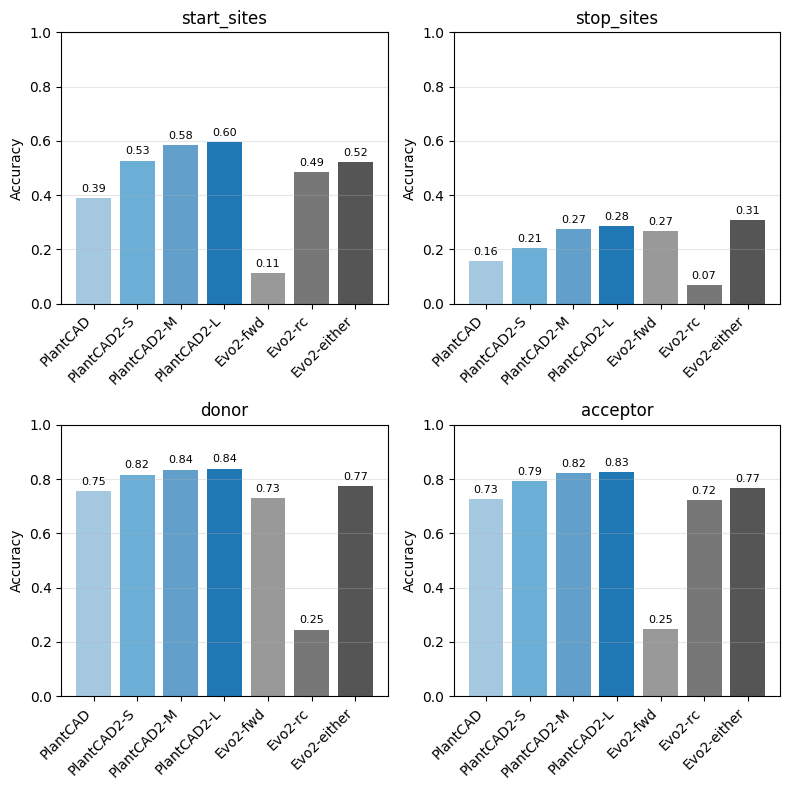

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes_flat = axes.flatten()

colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff', '#999999', '#777777', '#555555']
models = ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3', 'evo2_fwd', 'evo2_rc', 'evo2_either']
model_labels = ['PlantCAD', 'PlantCAD2-S', 'PlantCAD2-M', 'PlantCAD2-L', 'Evo2-fwd', 'Evo2-rc', 'Evo2-either']

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    accuracies = calculate_accuracies(df)
    
    # Get accuracy values for the single class (assuming it's 'All' or first available)
    class_name = list(accuracies.keys())[0]  # Get first available class
    acc_values = [accuracies[class_name][model] for model in models]
    
    # Simple bar plot with models as x-axis
    bars = ax.bar(range(len(models)), acc_values, color=colors, width=0.8)
    ax.grid(True, alpha = 0.3, axis = 'y')
    
    # Add value labels on bars
    for bar, acc in zip(bars, acc_values):
        if acc > 0:
            ax.annotate(f'{acc:.2f}',
                       xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    ax.set_ylabel('Accuracy')
    ax.set_title(dataset_name)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(model_labels, rotation=45, ha='right')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.15, 
                   wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.savefig('Token_accuracy_comparison.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()